# PyTorch 学习

In [2]:
import torch

print(torch.cuda.is_available())#检查是否有可用的GPU
print(torch.__version__)#查看PyTorch版本

False
2.3.1


张量（Tensor）:是深度学习与科学计算中的核心数据结构，可视为标量、向量、矩阵的高维推广。它由一组有序数值组成，并伴随形状（shape）、数据类型（dtype）与设备（device）等元信息。张量支持自动求导，能高效运行在 CPU/GPU/TPU 上，是现代框架（如 PyTorch、TensorFlow、JAX）表达模型参数、输入输出及中间特征的统一载体。

张量的创建方式有很多，大致分如下几种：

• 从数据直接创建

• 创建特张量

•随机创建张量

•创建线性张量


In [3]:
import torch
#1.通过标量创建张量

# 创建一个标量
t1=torch.tensor(1)#创建一个标量,默认类型为torch.int64
print(t1)
print(t1.dtype)

#2.通过列表创建张量,一维叫向量,二维叫矩阵
t2=torch.tensor([1,2,3])#创建一个1维张量,默认类型为torch.int64
print(t2)
print(t2.dtype)

# 创建一个2维张量(矩阵)
t3=torch.tensor([[1,2,3],[4,5,6]])#创建一个2维张量,默认类型为torch.int64
print(t3)
print(t3.dtype)

# 创建一个3维张量(立方体)
t4=torch.tensor([[[1,2,3],[4,5,6]],[[7,8,9],[10,11,12]]])#创建一个3维张量,默认类型为torch.int64
print(t4)
print(t4.dtype)


tensor(1)
torch.int64
tensor([1, 2, 3])
torch.int64
tensor([[1, 2, 3],
        [4, 5, 6]])
torch.int64
tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])
torch.int64


![alt text](image.png)

In [4]:
#1.张量转换为列表(通过numpy)
import torch
import numpy as np

# 创建一个张量
t5=torch.tensor([[1,2,3],[4,5,6]])

# 转换为NumPy数组
arr=t5.numpy()
print(arr)

# 转换为列表
lst=arr.tolist()
print(lst)

#2.张量转换为列表(直接转换)
t6=torch.tensor([[1,2,3],[4,5,6]])
print(t6)
print(t6.tolist())

[[1 2 3]
 [4 5 6]]
[[1, 2, 3], [4, 5, 6]]
tensor([[1, 2, 3],
        [4, 5, 6]])
[[1, 2, 3], [4, 5, 6]]


In [5]:
a=torch.randint(0,10,(2,3),dtype=torch.float32)#创建一个2*3的张量,元素值在[0,10)之间
print(a)
b=torch.rand(2,3 ,dtype=torch.float32)#创建一个2*3的张量,元素值在[0,1)之间
print(b)

print('-'*50)
#3.使用函数(不改变原张量)
#返回一个新的张量，不会修改原张量
print("a.add(b):",a.add(b))
print("a.sub(b):",a.sub(b))
print("a.mul(b):",a.mul(b))
print("a.div(b):",a.div(b))
print('-'*50)


#4.使用函数(改变原张量)
#执行原地操作，直接修改原张量，并返回修改后的自身
print("a.add_(b):",a.add_(b))
print("a.sub_(b):",a.sub_(b))
print("a.mul_(b):",a.mul_(b))
print("a.div_(b):",a.div_(b))

tensor([[3., 2., 6.],
        [5., 1., 7.]])
tensor([[0.7397, 0.1693, 0.1017],
        [0.6229, 0.5704, 0.6619]])
--------------------------------------------------
a.add(b): tensor([[3.7397, 2.1693, 6.1017],
        [5.6229, 1.5704, 7.6619]])
a.sub(b): tensor([[2.2603, 1.8307, 5.8983],
        [4.3771, 0.4296, 6.3381]])
a.mul(b): tensor([[2.2191, 0.3386, 0.6103],
        [3.1143, 0.5704, 4.6335]])
a.div(b): tensor([[ 4.0558, 11.8138, 58.9901],
        [ 8.0274,  1.7531, 10.5751]])
--------------------------------------------------
a.add_(b): tensor([[3.7397, 2.1693, 6.1017],
        [5.6229, 1.5704, 7.6619]])
a.sub_(b): tensor([[3., 2., 6.],
        [5., 1., 7.]])
a.mul_(b): tensor([[2.2191, 0.3386, 0.6103],
        [3.1143, 0.5704, 4.6335]])
a.div_(b): tensor([[3.0000, 2.0000, 6.0000],
        [5.0000, 1.0000, 7.0000]])


In [6]:
'''
张量的运算函数
常见的运算函数如下：
sum() 求和
mean() 求均值
max() 求最大值
min() 求最小值
argmax() 求最大值索引
argmin() 求最小值索引
'''
print(a.sum())
print(a.mean())
print(a.max())
print(a.min())
print(a.argmax())
print(a.argmin())

tensor(24.)
tensor(4.)
tensor(7.)
tensor(1.)
tensor(5)
tensor(4)


## 改变张量形状

> reshape(): 调整形状

> transpose(): 交换两个维度

> permute(): 重新排列多个维度

> unsqueeze()： 在指定维度上增加1个维度

> squeeze(): 删除大小为1的维度

> view()： 调整张量的形状，需要连续内存

> is_contiguous(): 判断是否内存连续

> contiguous(): 转换为连续内存

In [7]:
# 改变张量形状
import torch
x = torch.randn(2, 3, 4)
print(x.shape)
print(x.size()) # size() 方法和 shape 一样，返回张量的形状

# 1. 调整形状
x = x.reshape(2, 12) 
print("x.shape1:", x.shape)
x = x.reshape(-1, 3) # 计算行数
print("x.shape2:", x.shape)
# 调整为2行12列
# 不限制行数，列数调整为3列（会自动计算行数）
print("x.shape3:", x.shape)

# 2. 交换维度
x = torch.randn(2, 3, 4)
x = x.transpose(1, 2)
print(x.shape)

# 3. 重新排列多个维度
# 第3维度变为第1维，第2维变为第2维，第1维变为第3维
x = x.permute(2, 1, 0)
print(x.shape)

# 4. 在指定维度上增加一个维度，会添加形状为1的维度
x = x.unsqueeze(dim=2)
print(x.shape)

# 5. 在指定维度上删除一个维度，会删除形状为1的维度（如果该维度不存在形状为1的维度，则返回原张量）
x = x.squeeze(dim=1)
print(x.shape)

# 6. 调整形状，需要连续内存
# 经过升维和降维操作，张量的数据存储位置（内存）可能会改变，所以内存可能不连续
# 使用view方法，如果内存不连续，那么会报错
# x = x.view(3, -1)
# print(x)
# 6. 判断是否是连续内存(不重要)
print(x.is_contiguous())  

# 7. 转换为连续内存(不重要)
x = x.contiguous()
print(x.is_contiguous())

# 8. 调整形状，需要连续内存(不重要)
x = x.view(3, -1)
print(x.shape)

torch.Size([2, 3, 4])
torch.Size([2, 3, 4])
x.shape1: torch.Size([2, 12])
x.shape2: torch.Size([8, 3])
x.shape3: torch.Size([8, 3])
torch.Size([2, 4, 3])
torch.Size([3, 4, 2])
torch.Size([3, 4, 1, 2])
torch.Size([3, 4, 1, 2])
False
True
torch.Size([3, 8])


In [8]:
import torch
# 一维tensor，元素为1,2,3
tensor_1d = torch.tensor([1, 2, 3])
print(tensor_1d)
print(tensor_1d.shape)
print('-'*50)

tensor_3d=a.unsqueeze(0)#在指定维度上增加1个维度
print(tensor_3d)
print(tensor_3d.shape)


tensor([1, 2, 3])
torch.Size([3])
--------------------------------------------------
tensor([[[3.0000, 2.0000, 6.0000],
         [5.0000, 1.0000, 7.0000]]])
torch.Size([1, 2, 3])


## 自动微分模块

自动微分模块，其实就是根据损失函数Loss自动求得权重w和偏置b的梯度。

### 示例 1：标量线性模型（单输入单输出）

In [9]:
#示例 1：标量线性模型（单输入单输出）
import torch

# 1. 准备数据: 输入特征 x 和目标值 y
x = torch.tensor(5.0)# 输入特征 x
y = torch.tensor(0.0)# 注意：应为浮点数，否则 matmul/乘法可能出错

# 2. 初始化参数: 权重 w 和偏置 b
w = torch.tensor(1.0, requires_grad=True)#requires_grad=True表示需要计算梯度
b = torch.tensor(3.0, requires_grad=True)

# 3. 前向传播：线性模型 z = w * x + b
z = w * x + b

# 4. 计算损失（MSE）
loss_fn = torch.nn.MSELoss()#调用MSELoss损失函数
loss = loss_fn(z, y)

# 5. 反向传播
loss.backward()

# 6. 打印梯度
print("w.grad:", w.grad)
print("b.grad:", b.grad)

w.grad: tensor(80.)
b.grad: tensor(16.)


### 示例 2：矩阵形式（多输入多输出，全连接层）

In [10]:
#示例 2：矩阵形式（多输入多输出，全连接层）
import torch

# 1. 准备数据: 输入 x (2 samples, 5 features), 目标 y (2 samples, 3 outputs)
x = torch.ones(2, 5)
y = torch.zeros(2, 3)

# 2. 初始化参数
w = torch.randn(5, 3, requires_grad=True)  # weight matrix: 5 inputs → 3 outputs
b = torch.randn(3, requires_grad=True)     # bias: length 3

# 3. 前向传播: z = x @ w + b
z = torch.matmul(x, w) + b

# 4. 计算损失
loss_fn = torch.nn.MSELoss()
loss = loss_fn(z, y)

# 5. 反向传播
loss.backward()

# 6. 打印梯度
print("w.grad:\n", w.grad)
print("b.grad:\n", b.grad)

w.grad:
 tensor([[-1.8463, -0.4118, -0.6307],
        [-1.8463, -0.4118, -0.6307],
        [-1.8463, -0.4118, -0.6307],
        [-1.8463, -0.4118, -0.6307],
        [-1.8463, -0.4118, -0.6307]])
b.grad:
 tensor([-1.8463, -0.4118, -0.6307])


### 3.线性回归案例

要使用的API：

使用 PyTorch 的 nn.MSELoss() 代替自定义的平方损失函数

使用 PyTorch 的 data.DataLoader 代替自定义的数据加载器

使用 PyTorch 的 optim.SGD 代替自定义的优化器

使用 PyTorch 的 nn.Linear 代替自定义的假设函数

通过PyTorch的API，我们可以实现线性回归模型的训练。

In [11]:
# 线性回归案例
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import numpy as np

# 1. 生成数据
# 生成回归数据集：100个样本，1个特征，加入噪声10，偏置1.5，返回真实系数，固定随机种子保证可复现
x, y, coef = make_regression(
    n_samples=100,      # 样本数量
    n_features=1,       # 特征数量（单变量）
    noise=10,           # 噪声强度
    bias=1.5,           # 截距偏置
    coef=True,          # 返回真实回归系数
    random_state=22     # 随机种子，确保结果可复现
)

# 2. 数据可视化（可选）
# plt.scatter(x, y)
# plt.show()

# 3. 构造Dataset和DataLoader
# 将numpy数组转换为torch张量
x_tensor = torch.from_numpy(x.astype(np.float32))
y_tensor = torch.from_numpy(y.astype(np.float32)).view(-1, 1)

# 创建TensorDataset
dataset = TensorDataset(x_tensor, y_tensor)

# 创建DataLoader，批次大小为16，打乱数据
'''
batch_size=16,表示每个批次包含16个样本，每次训练时使用这16个样本进行更新模型参数。
shuffle=True,表示在每个epoch开始前，随机打乱数据顺序，增加模型的泛化能力。
'''
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


# 4. 搭建模型
# 定义线性回归模型：输入特征数为1，输出特征数为1
model = nn.Linear(in_features=1, out_features=1)

# 5. 定义损失函数和优化器
# 使用均方误差损失
criterion = nn.MSELoss()
# 使用随机梯度下降优化器，学习率为0.01
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 6. 训练模型
num_epochs = 40  # 训练轮数
for epoch in range(num_epochs):
    for batch_x, batch_y in dataloader:
        # 前向传播
        outputs = model(batch_x)#正向传播，计算预测值
        loss = criterion(outputs, batch_y)#计算损失

        # 反向传播和优化
        optimizer.zero_grad()  # 清零梯度
        loss.backward()        # 反向传播
        optimizer.step()       # 更新参数,w=w-学习率*梯度[w=w-lr*grad]

    # 每10轮打印一次损失
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 7. 查看训练后的模型参数
print("训练后的权重:", model.weight.item())
print("训练后的偏置:", model.bias.item())
print("真实系数:", coef)


Epoch [10/40], Loss: 216.1301
Epoch [20/40], Loss: 101.1428
Epoch [30/40], Loss: 62.2099
Epoch [40/40], Loss: 76.9216
训练后的权重: 38.162193298339844
训练后的偏置: 1.202539086341858
真实系数: 39.80551570183919


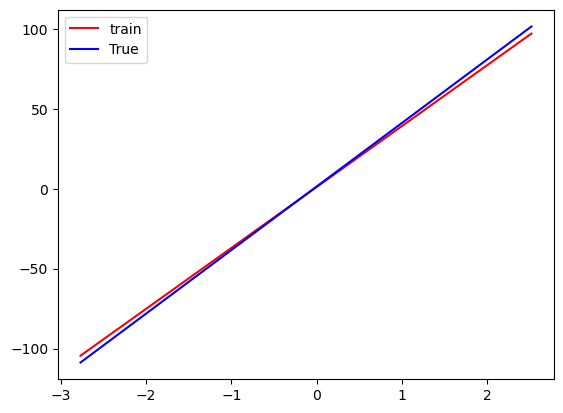

In [ ]:
# 在x的取值范围内均匀生成100个点，用于绘制平滑曲线
x=torch.linspace(x.min(),x.max(),100)
# 根据模型参数计算预测值
y_train_pred=torch.tensor([v*model.weight+model.bias for v in x])
# 根据真实系数计算真实值，截距为1.5
y_true=torch.tensor([v*coef+1.5 for v in x])

#绘制曲线
plt.plot(x,y_train_pred,'r',label='train')
plt.plot(x,y_true,'b',label='True')
plt.legend()
plt.show()


In [15]:
'''
# 3. 使用 PyTorch 模拟线性回归

# 3.1 构造数据集对象 Dataset
# 注意：sklearn 返回的是 numpy 数组，需转为 tensor
# 将 numpy 数组 x 转换为 PyTorch 的 FloatTensor，形状为 (100, 1)
x_tensor = torch.from_numpy(x).float()  # shape: (100, 1)
# 将 numpy 数组 y 转换为 PyTorch 的 FloatTensor，形状为 (100,)
y_tensor = torch.from_numpy(y).float()  # shape: (100,)

# 使用 TensorDataset 将输入特征 x_tensor 与目标值 y_tensor 打包成数据集
dataset = TensorDataset(x_tensor, y_tensor)

# 3.2 创建数据加载器 DataLoader
# DataLoader 用于批量加载数据，batch_size=10 表示每个批次 10 个样本，shuffle=True 表示每轮打乱顺序
dataLoader = DataLoader(dataset, batch_size=10, shuffle=True)

# 3.3 构造模型
# 使用 nn.Linear 定义线性回归模型，输入特征维度为 1，输出维度为 1（单变量线性回归）
model = nn.Linear(in_features=1, out_features=1)

# 3.4 构造损失函数和优化器
# 使用均方误差损失函数（MSE）来衡量预测值与真实值之间的差距
loss_fn = nn.MSELoss()
# 使用随机梯度下降（SGD）优化器，学习率设为 0.01，用于更新模型参数
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 3.5 训练模型
# 设置训练轮数为 100 轮
epochs = 100
# 用于记录每一轮的平均损失值，便于后续绘图
losses = []

# 开始训练循环
for epoch in range(epochs):
    # 初始化当前轮次的总损失和批次计数
    total_loss = 0.0
    num_batches = 0
    # 遍历每个批次的数据
    for train_x, train_y in dataLoader:
        # 前向传播：将输入数据传入模型，得到预测值
        y_pred = model(train_x)  # train_x 已是 float32

        # 计算损失：将预测值与真实值进行比较，注意 train_y 需要升维为 (batch, 1) 以匹配 y_pred 的形状
        loss = loss_fn(y_pred, train_y.unsqueeze(1))

        # 反向传播：清零梯度，计算当前批次梯度，并根据梯度更新模型参数
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 累加当前批次的损失值，并增加批次计数
        total_loss += loss.item()
        num_batches += 1

    # 计算当前轮次的平均损失
    avg_loss = total_loss / num_batches
    losses.append(avg_loss)
    # 可选：打印每轮损失
    # print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# 4. 绘制损失变化曲线
# 创建新图，设置图像大小为 8x4 英寸
plt.figure(figsize=(8, 4))
# 绘制训练过程中每一轮的平均损失
plt.plot(range(epochs), losses)
# 设置图表标题和坐标轴标签
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
# 显示网格线并展示图像
plt.grid(True)
plt.show()

# 5. 绘制拟合曲线
# 创建新图，设置图像大小为 8x6 英寸
plt.figure(figsize=(8, 6))
# 绘制原始数据点，alpha=0.6 表示透明度为 60%
plt.scatter(x, y, label='Data', alpha=0.6)

# 生成用于绘图的 x 值：在原始数据范围内均匀生成 100 个点，形状为 (100, 1)
x_plot = torch.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# 使用训练好的模型进行预测，并关闭梯度计算以节省内存
with torch.no_grad():
    # 模型预测结果，squeeze 去掉多余的维度，再转为 numpy 数组
    y_train_pred = model(x_plot).squeeze().numpy()

# 计算真实函数值：根据真实权重 coef 和偏置 1.5 计算对应的 y 值
y_true = coef * x_plot.squeeze().numpy() + 1.5

# 绘制模型预测曲线（红色）和真实函数曲线（绿色虚线）
plt.plot(x_plot.numpy(), y_train_pred, label='Trained Model', color='red')
plt.plot(x_plot.numpy(), y_true, label='True Function', color='green', linestyle='--')

# 显示图例、网格线，并设置图表标题
plt.legend()
plt.grid(True)
plt.title("Linear Regression Fit")
plt.show()

# 可选：打印学到的参数
# 输出模型学习到的权重和偏置，并与真实值进行对比
print(f"Learned weight: {model.weight.item():.4f}, bias: {model.bias.item():.4f}")
print(f"True weight: {coef:.4f}, true bias: 1.5")
'''

'\n# 3. 使用 PyTorch 模拟线性回归\n\n# 3.1 构造数据集对象 Dataset\n# 注意：sklearn 返回的是 numpy 数组，需转为 tensor\n# 将 numpy 数组 x 转换为 PyTorch 的 FloatTensor，形状为 (100, 1)\nx_tensor = torch.from_numpy(x).float()  # shape: (100, 1)\n# 将 numpy 数组 y 转换为 PyTorch 的 FloatTensor，形状为 (100,)\ny_tensor = torch.from_numpy(y).float()  # shape: (100,)\n\n# 使用 TensorDataset 将输入特征 x_tensor 与目标值 y_tensor 打包成数据集\ndataset = TensorDataset(x_tensor, y_tensor)\n\n# 3.2 创建数据加载器 DataLoader\n# DataLoader 用于批量加载数据，batch_size=10 表示每个批次 10 个样本，shuffle=True 表示每轮打乱顺序\ndataLoader = DataLoader(dataset, batch_size=10, shuffle=True)\n\n# 3.3 构造模型\n# 使用 nn.Linear 定义线性回归模型，输入特征维度为 1，输出维度为 1（单变量线性回归）\nmodel = nn.Linear(in_features=1, out_features=1)\n\n# 3.4 构造损失函数和优化器\n# 使用均方误差损失函数（MSE）来衡量预测值与真实值之间的差距\nloss_fn = nn.MSELoss()\n# 使用随机梯度下降（SGD）优化器，学习率设为 0.01，用于更新模型参数\noptimizer = optim.SGD(model.parameters(), lr=0.01)\n\n# 3.5 训练模型\n# 设置训练轮数为 100 轮\nepochs = 100\n# 用于记录每一轮的平均损失值，便于后续绘图\nlosses = []\n\n# 开始训练循环\nfor epoch in range(epochs):\n    # 初始化

## Dataset

In [ ]:
# 自定义 Dataset
import torch
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self):
        # 1. 初始化数据，例如读取文件
        self.data = ['李云龙','楚云飞','秀芹','赵刚','丁伟','孔捷','常乃超','魏大勇']
        self.total = len(self.data)

    def __getitem__(self, index):
        # 2. 获取索引对应的数据
        return self.data[index]

    def __len__(self):
        # 3. 返回数据集的长度
        return self.total


dataset = MyDataset()
print(dataset[1])  # 输出: 楚云飞

楚云飞


In [20]:
# 创建DataLoader
from torch.utils.data import DataLoader
# 创建DataLoader
# batchsize: 每次批次的大小
# shuffle: 是否打乱数据
dataloader = DataLoader(MyDataset(), batch_size=2, shuffle=True)

# 遍历DataLoader
for batch in dataloader:
    print(batch)


['赵刚', '秀芹']
['魏大勇', '孔捷']
['丁伟', '常乃超']
['楚云飞', '李云龙']
